In [ ]:
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
# Import libraries
import os

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text preprocessing & NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK resources (only once)
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Path to downloaded dataset
import kagglehub

In [ ]:
# Download latest version from Kaggle
path = kagglehub.dataset_download("ashishkumarak/netflix-reviews-playstore-daily-updated")

print("Path to dataset files:", path)

# Check files in the downloaded folder
print("\nFiles in the dataset directory:")
print(os.listdir(path))

# Load the CSV file (the main file is usually named 'netflix_reviews.csv')
file_path = os.path.join(path, "netflix_reviews.csv")

# Read dataset
df = pd.read_csv(file_path, nrows = 40000)

Using Colab cache for faster access to the 'netflix-reviews-playstore-daily-updated' dataset.
Path to dataset files: /kaggle/input/netflix-reviews-playstore-daily-updated

Files in the dataset directory:
['netflix_reviews.csv']


In [ ]:
# ---- DATA OVERVIEW ----
print("\n Dataset Overview")
print("-" * 40)

# Shape of dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Display first few rows
print("\n First 5 Rows:")
display(df.head())

# Column info
print("\n Column Information:")
print(df.info())

# Missing values summary
print("\n Missing Values:")
print(df.isnull().sum())

# Basic statistics (for numeric columns)
print("\n Statistical Summary:")
print(df.describe())


 Dataset Overview
----------------------------------------
Rows: 40000, Columns: 8

 First 5 Rows:


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,f64420a0-19d4-4a3b-b6b7-d7a0854b9248,Ian Oliver Santos,there's some anime that has no English subtitl...,1,0,9.37.0 build 7 63508,2025-10-15 11:48:35,9.37.0 build 7 63508
1,1b581d18-16b8-4e09-ae94-9cc7543050e0,Shah Khalid,zero star becose this vary expensive,1,0,NaN,2025-10-15 11:46:46,NaN
2,9c67013a-7bf1-480f-8e53-944b79ef504d,Jyoti,good app,5,0,NaN,2025-10-15 11:38:02,NaN
3,fbade5b6-9977-46aa-bab7-cbafe692234c,Thinker,powerfull application for to watch the ULTRA H...,5,0,9.37.0 build 7 63508,2025-10-15 11:31:41,9.37.0 build 7 63508
4,51fad58b-4fd9-406d-adf8-3fed13b47578,KingJustice98,Expensive. New sign in screen has unnecessary ...,2,0,9.37.0 build 7 63508,2025-10-15 11:11:52,9.37.0 build 7 63508



 Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              40000 non-null  object
 1   userName              39999 non-null  object
 2   content               39994 non-null  object
 3   score                 40000 non-null  int64 
 4   thumbsUpCount         40000 non-null  int64 
 5   reviewCreatedVersion  30564 non-null  object
 6   at                    40000 non-null  object
 7   appVersion            30564 non-null  object
dtypes: int64(2), object(6)
memory usage: 2.4+ MB
None

 Missing Values:
reviewId                   0
userName                   1
content                    6
score                      0
thumbsUpCount              0
reviewCreatedVersion    9436
at                         0
appVersion              9436
dtype: int64

 Statistical Summary:
              score  thumbsUp

In [ ]:
# DATA CLEANING AND PREPROCESSING

# Make a copy of the raw dataset (backup)
df_raw = df.copy()

# Check for duplicate reviews (based on reviewId)
duplicate_count = df.duplicated(subset='reviewId').sum()
print(f"Number of duplicate reviewId entries: {duplicate_count}")

# Drop duplicates if any
df.drop_duplicates(subset='reviewId', inplace=True)

# Handle missing values

# Drop rows where 'content' (review text) is missing, since we need it for sentiment analysis
df = df.dropna(subset=['content'])

# Fill missing usernames with 'Anonymous'
df['userName'] = df['userName'].fillna('Anonymous')

# Fill missing 'reviewCreatedVersion' and 'appVersion' with 'Unknown'
df['reviewCreatedVersion'] = df['reviewCreatedVersion'].fillna('Unknown')
df['appVersion'] = df['appVersion'].fillna('Unknown')

# Convert date column 'at' to datetime type
df['at'] = pd.to_datetime(df['at'], errors='coerce')

# Remove rows where review text is too short or blank after stripping whitespace
df['content'] = df['content'].astype(str).str.strip()
df = df[df['content'].str.len() > 2]

Number of duplicate reviewId entries: 991


In [ ]:
# ADVANCED TEXT PREPROCESSING

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string

# Download required nltk resources (only once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Initialize tools
stop_words = set(stopwords.words('english'))
# Keep some negation words as they influence sentiment
negation_words = {"no", "not", "nor", "don't", "didn't", "won't", "isn't", "aren't", "wasn't", "weren't", "couldn't", "shouldn't", "wouldn't", "haven't", "hasn't", "hadn't"}
custom_stopwords = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Perform tailored cleaning and preprocessing for sentiment analysis.
    Steps:
    1. Lowercase text
    2. Remove URLs, mentions, hashtags
    3. Remove punctuation and numbers
    4. Tokenize
    5. Remove stopwords (but keep negations)
    6. Lemmatize tokens
    7. Join cleaned tokens back into text
    """
    # Lowercase
    text = text.lower()

    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation, digits, and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords but keep negation words
    tokens = [word for word in tokens if word not in custom_stopwords and len(word) > 2]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back into cleaned sentence
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Apply preprocessing to all reviews
df['clean_content'] = df['content'].astype(str).apply(preprocess_text)

# Preview the results
print("\n Sample of preprocessed reviews:")
print(df[['content', 'clean_content']].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



 Sample of preprocessed reviews:
                                             content  \
0  there's some anime that has no English subtitl...   
1               zero star becose this vary expensive   
2                                           good app   
3  powerfull application for to watch the ULTRA H...   
4  Expensive. New sign in screen has unnecessary ...   
5                                               good   
6  I have opened the Netflix I am a very old user...   
7                                      Perfect 😇100%   
8                                        very good 💯   
9                                           best use   

                                       clean_content  
0                    anime english subtitle terrible  
1                    zero star becose vary expensive  
2                                           good app  
3            powerfull application watch ultra movie  
4  expensive new sign screen unnecessary icon pro...  
5                  

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set visualization style
sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

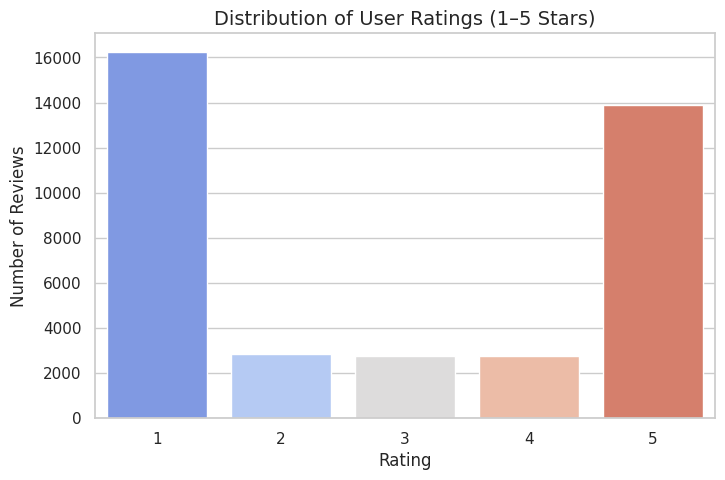

In [ ]:
# Rating Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='score', data=df, palette='coolwarm')
plt.title("Distribution of User Ratings (1–5 Stars)", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

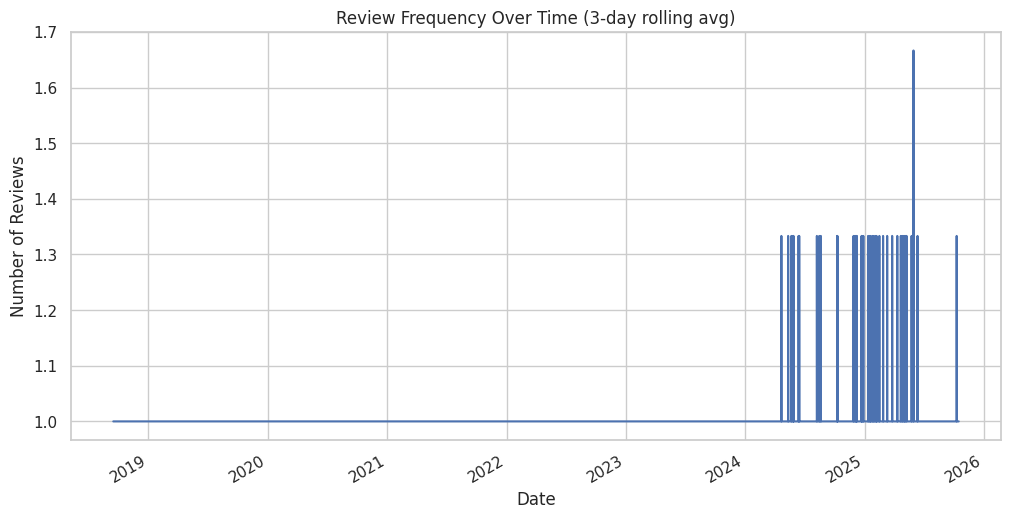

In [ ]:
# Review Activity Over Time
df_sorted = df.sort_values(by='at')
plt.figure(figsize=(12,6))
df_sorted['at'].value_counts().sort_index().rolling(3).mean().plot()
plt.title("Review Frequency Over Time (3-day rolling avg)")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

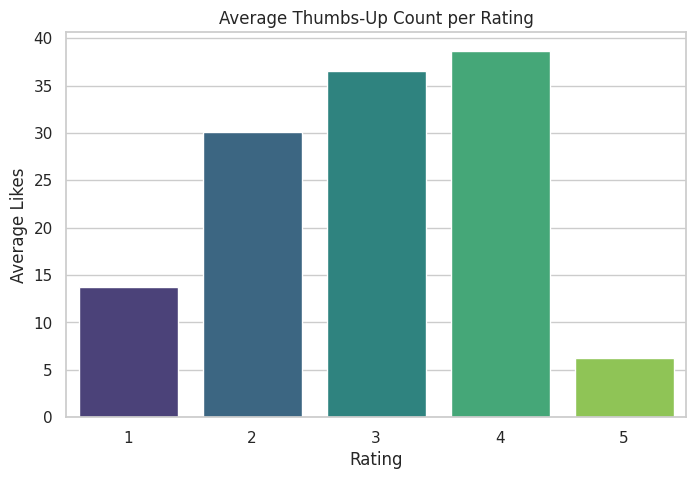

In [ ]:
# Average Thumbs-Up Count by Rating
plt.figure(figsize=(8,5))
sns.barplot(x='score', y='thumbsUpCount', data=df, estimator=np.mean, ci=None, palette='viridis')
plt.title("Average Thumbs-Up Count per Rating")
plt.xlabel("Rating")
plt.ylabel("Average Likes")
plt.show()

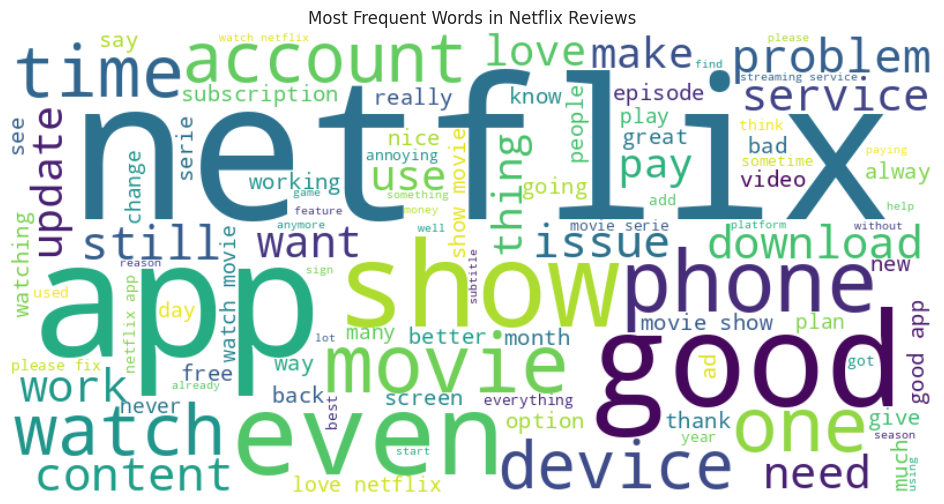

In [ ]:
# WordCloud — Overall
all_text = ' '.join(df['clean_content'])
wordcloud_all = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Netflix Reviews")
plt.show()

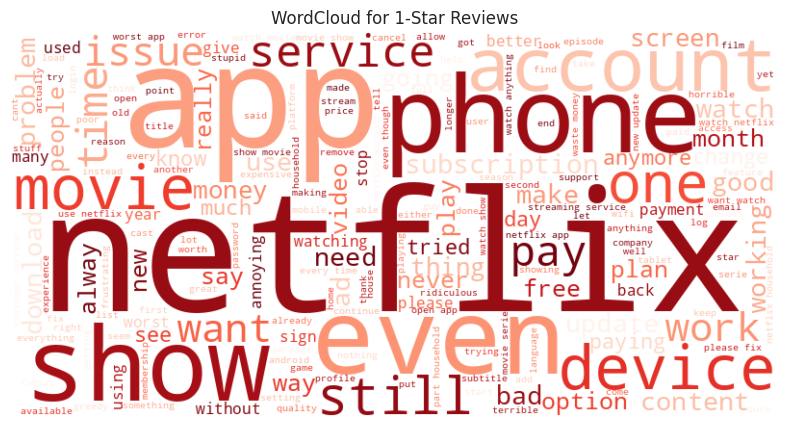

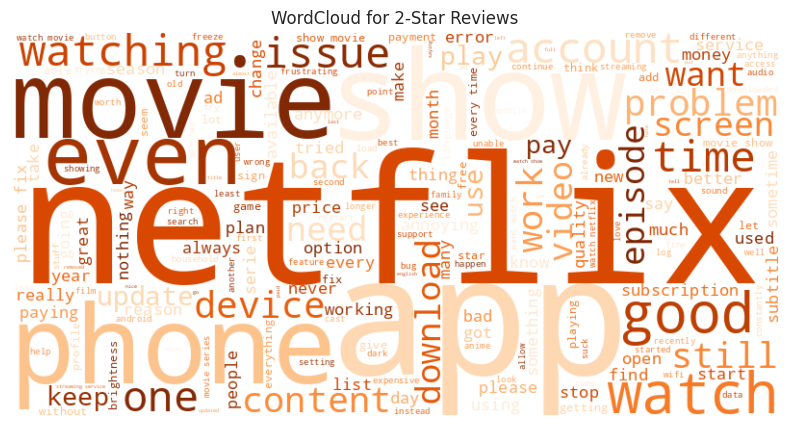

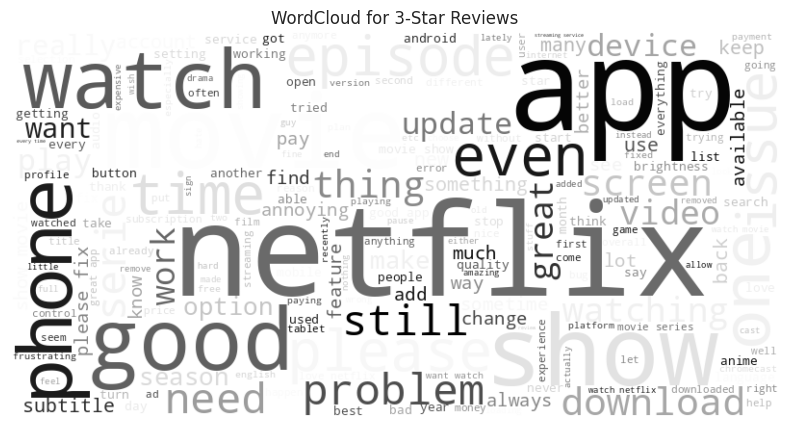

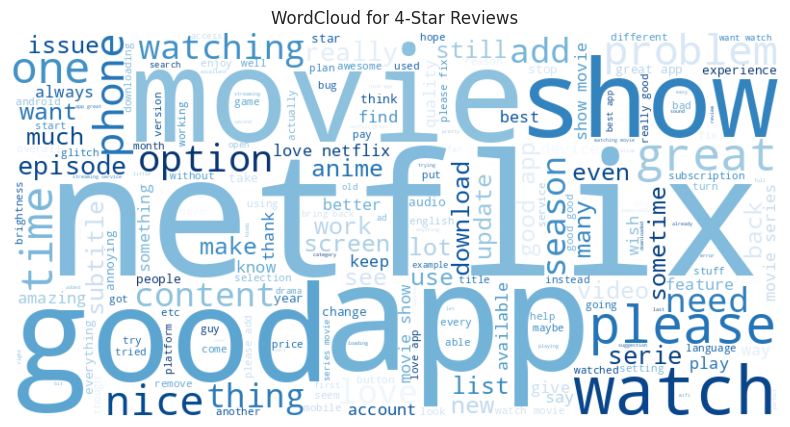

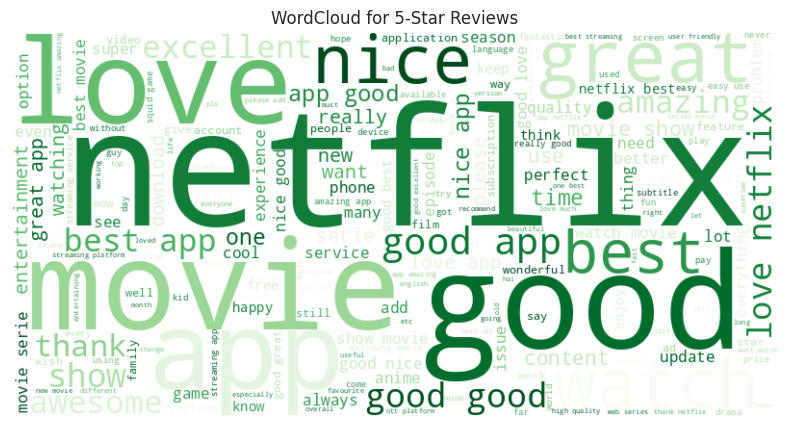

In [ ]:
# WordClouds by Rating Category
def plot_wordcloud_for_rating(score_value, color):
    subset = df[df['score'] == score_value]
    text = ' '.join(subset['clean_content'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {score_value}-Star Reviews")
    plt.show()

# Low (1–2 stars)
plot_wordcloud_for_rating(1, 'Reds')
plot_wordcloud_for_rating(2, 'Oranges')

# Neutral (3 stars)
plot_wordcloud_for_rating(3, 'Greys')

# Positive (4–5 stars)
plot_wordcloud_for_rating(4, 'Blues')
plot_wordcloud_for_rating(5, 'Greens')

In [ ]:
# Correlation Check (Thumbs vs Rating)
corr = df[['score', 'thumbsUpCount']].corr()
print("\n Correlation between Rating and Thumbs-Up Count:")
print(corr)


 Correlation between Rating and Thumbs-Up Count:
                  score  thumbsUpCount
score          1.000000      -0.017742
thumbsUpCount -0.017742       1.000000


In [ ]:
# SENTIMENT LABELING & FEATURE EXTRACTION

from sklearn.feature_extraction.text import TfidfVectorizer

# Sentiment Labeling based on Rating
def label_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['score'].apply(label_sentiment)

# Verify distribution
print(" Sentiment Distribution:")
print(df['sentiment'].value_counts())

 Sentiment Distribution:
sentiment
Negative    19106
Positive    16648
Neutral      2778
Name: count, dtype: int64


In [ ]:
# TF-IDF Vectorization
# Use TF-IDF (Term Frequency–Inverse Document Frequency)
# to convert text into numerical features.

tfidf = TfidfVectorizer(
    max_features=5000,        # Limit vocabulary size
    ngram_range=(1, 2),       # Include unigrams & bigrams
    min_df=5,                 # Ignore rare words
    max_df=0.8,               # Ignore overly common words
    stop_words='english'      # Remove generic stopwords
)

# Fit and transform the cleaned text
X = tfidf.fit_transform(df['clean_content'])
y = df['sentiment']

print(f"\n TF-IDF shape: {X.shape}")
print("Example feature names:", tfidf.get_feature_names_out()[:20])


 TF-IDF shape: (38532, 5000)
Example feature names: ['aap' 'ability' 'ability download' 'able' 'able access' 'able cast'
 'able download' 'able log' 'able login' 'able open' 'able play'
 'able share' 'able sign' 'able stream' 'able use' 'able watch' 'abroad'
 'absolute' 'absolute garbage' 'absolute trash']


In [ ]:
# MODEL TRAINING & EVALUATION

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 30825
Testing samples: 7707



 Model Performance Metrics:
Accuracy: 0.8182

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.89      0.85      3821
     Neutral       0.25      0.01      0.02       556
    Positive       0.82      0.87      0.85      3330

    accuracy                           0.82      7707
   macro avg       0.63      0.59      0.57      7707
weighted avg       0.78      0.82      0.79      7707



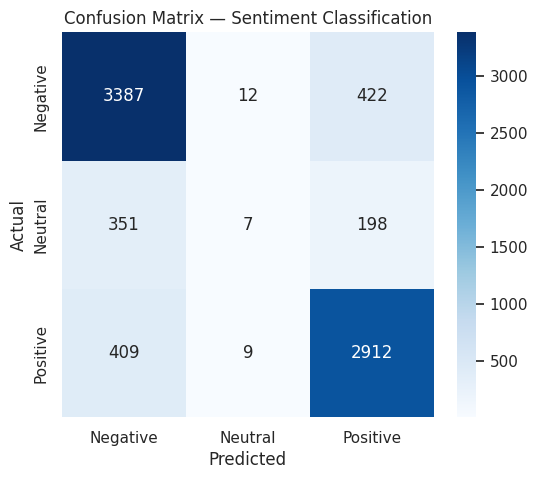

In [ ]:
# Model Training
log_reg = LogisticRegression(
    max_iter=300,          # Increase iterations for convergence
    solver='lbfgs',        # Good default for multiclass
    n_jobs=-1              # Use all cores
)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print("\n Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix — Sentiment Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Training & Evaluating: Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.74      0.79      3821
     Neutral       0.19      0.42      0.26       556
    Positive       0.85      0.82      0.83      3330

    accuracy                           0.75      7707
   macro avg       0.63      0.66      0.63      7707
weighted avg       0.81      0.75      0.77      7707



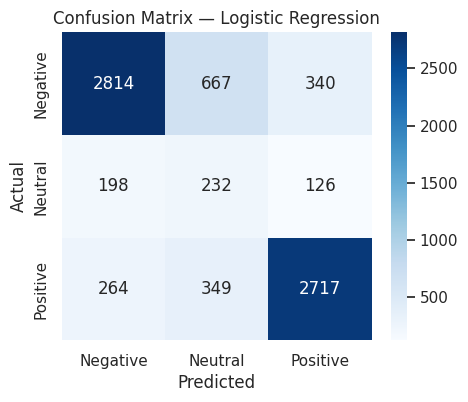

Accuracy: 0.7478

--- Training & Evaluating: LightGBM ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.750971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 77030
[LightGBM] [Info] Number of data points in the train set: 30825, number of used features: 2392
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.76      0.80      3821
     Neutral       0.18      0.31      0.23       556
    Positive       0.82      0.83      0.83      3330

    accuracy                           0.76      7707
   macro avg       0.62      0.63      0.62      7707
weighted avg       0.79      0.76      0.77      7707



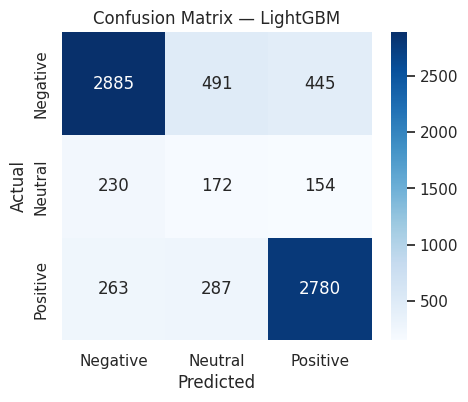

Accuracy: 0.7574

--- Training & Evaluating: SVM (Linear) ---
Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.80      0.82      3821
     Neutral       0.18      0.21      0.19       556
    Positive       0.83      0.85      0.84      3330

    accuracy                           0.78      7707
   macro avg       0.61      0.62      0.62      7707
weighted avg       0.79      0.78      0.78      7707



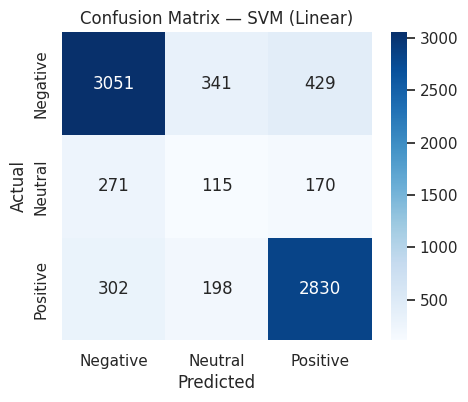

Accuracy: 0.7780

 Model Accuracy Comparison:
Logistic Regression: 0.7478
LightGBM: 0.7574
SVM (Linear): 0.7780


In [ ]:
import lightgbm as lgb
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced', n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight='balanced',
        n_jobs=-1
    ),
    "SVM (Linear)": LinearSVC(max_iter=5000, class_weight='balanced')
}

results = {}

# Train and evaluate each model
for name, clf in models.items():
    print(f"\n--- Training & Evaluating: {name} ---")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=['Negative','Neutral','Positive'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Neutral','Positive'],
                yticklabels=['Negative','Neutral','Positive'])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Save accuracy for comparison
    acc = (y_pred == y_test).mean()
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")

# Compare all models
print("\n Model Accuracy Comparison:")
for k,v in results.items():
    print(f"{k}: {v:.4f}")

In [ ]:
#  SBERT EMBEDDINGS + CLASSIFICATION

# Install / import necessary libraries
# !pip install -U sentence-transformers scikit-learn seaborn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load SBERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # fast and accurate

# Compute embeddings for all reviews
print("Generating SBERT embeddings...")
embeddings = sbert_model.encode(df['clean_content'].tolist(), batch_size=256, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating SBERT embeddings...


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

In [ ]:
# Prepare features and labels
X = embeddings
y = df['sentiment']

# Train-test split (stratify to keep class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.69      0.77      3821
     Neutral       0.17      0.50      0.26       556
    Positive       0.86      0.80      0.83      3330

    accuracy                           0.72      7707
   macro avg       0.63      0.66      0.62      7707
weighted avg       0.82      0.72      0.76      7707



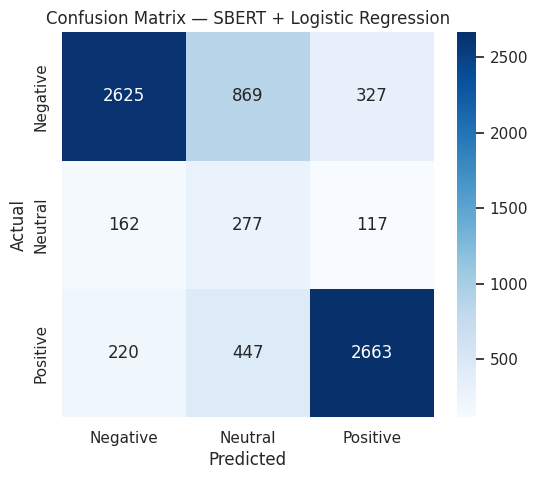


Sample of predicted sentiments:
                                       clean_content sentiment  \
0                    anime english subtitle terrible  Negative   
1                    zero star becose vary expensive  Negative   
2                                           good app  Positive   
3            powerfull application watch ultra movie  Positive   
4  expensive new sign screen unnecessary icon pro...  Negative   
5                                               good   Neutral   
6  opened netflix old user getting lot box proble...  Negative   
7                                            perfect  Positive   
8                                               good  Positive   
9                                           best use  Positive   

  predicted_sentiment  
0             Neutral  
1            Negative  
2            Positive  
3            Positive  
4             Neutral  
5            Positive  
6            Negative  
7            Positive  
8            Positive  


In [ ]:
# Train Logistic Regression classifier with balanced class weights
clf = LogisticRegression(max_iter=400, class_weight='balanced', n_jobs=-1)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate performance
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title("Confusion Matrix — SBERT + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Add predicted sentiment to original dataframe
df['predicted_sentiment'] = clf.predict(embeddings)
print("\nSample of predicted sentiments:")
print(df[['clean_content','sentiment','predicted_sentiment']].head(10))


--- Training & Evaluating: Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.69      0.77      3821
     Neutral       0.17      0.50      0.26       556
    Positive       0.86      0.80      0.83      3330

    accuracy                           0.72      7707
   macro avg       0.63      0.66      0.62      7707
weighted avg       0.82      0.72      0.76      7707



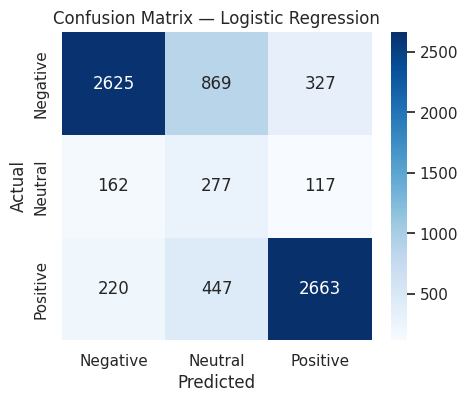

Accuracy: 0.7221

--- Training & Evaluating: LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.279886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 30825, number of used features: 384
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.87      0.85      3821
     Neutral       0.25      0.14      0.18       556
    Positive       0.84      0.85      0.85      3330

    accuracy                           0.81      7707
   macro avg       0.64      0.62      0.62      7707
weighted avg       0.79      0.81      0.80      7707



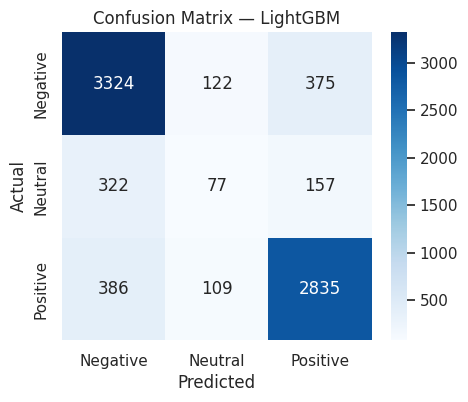

Accuracy: 0.8091

--- Training & Evaluating: SVM (Linear) ---
Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84      3821
     Neutral       0.24      0.21      0.22       556
    Positive       0.85      0.85      0.85      3330

    accuracy                           0.80      7707
   macro avg       0.64      0.63      0.64      7707
weighted avg       0.80      0.80      0.80      7707



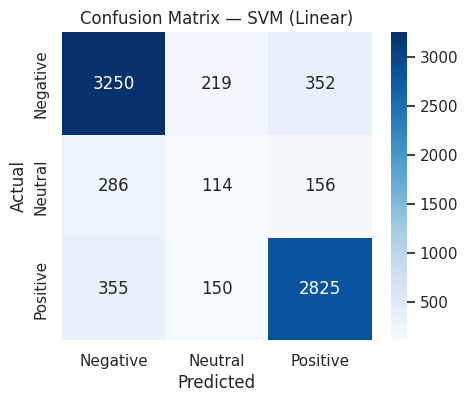

Accuracy: 0.8030

 Model Accuracy Comparison:
Logistic Regression: 0.7221
LightGBM: 0.8091
SVM (Linear): 0.8030


In [ ]:
import lightgbm as lgb
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced', n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight='balanced',
        n_jobs=-1
    ),
    "SVM (Linear)": LinearSVC(max_iter=5000, class_weight='balanced')
}

results = {}

# Train and evaluate each model
for name, clf in models.items():
    print(f"\n--- Training & Evaluating: {name} ---")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=['Negative','Neutral','Positive'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Neutral','Positive'],
                yticklabels=['Negative','Neutral','Positive'])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Save accuracy for comparison
    acc = (y_pred == y_test).mean()
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")

# Compare all models
print("\n Model Accuracy Comparison:")
for k,v in results.items():
    print(f"{k}: {v:.4f}")